<a href="https://colab.research.google.com/github/MiguelGonzalez197/Proyectos-Deep-Learning/blob/Miguel-Gonzalez/CodigoCNN%2BLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Instalación de dependencias

In [1]:
!pip install nltk -q
!pip install scikit-learn -q
!pip install matplotlib seaborn -q

## 2. Importación de librerías

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, MaxPooling1D,
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

np.random.seed(42)
tf.random.set_seed(42)

print('Librerías importadas correctamente')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

Librerías importadas correctamente
TensorFlow version: 2.20.0
GPU disponible: True


## 3. Carga del Dataset



In [3]:
from google.colab import files
import zipfile

print('Sube el archivo sentiment140.zip descargado de Kaggle:')
uploaded = files.upload()

# Descomprimir
with zipfile.ZipFile('sentiment140.zip', 'r') as z:
    z.extractall('.')
    print('Archivos dentro del ZIP:', z.namelist())

DATASET_PATH = 'training.1600000.processed.noemoticon.csv'
COLUMN_NAMES = ['target', 'id', 'date', 'flag', 'user', 'text']

print('\nCargando dataset')
df = pd.read_csv(DATASET_PATH, encoding='latin-1', names=COLUMN_NAMES)

print(f'Dataset cargado: {df.shape[0]:,} filas, {df.shape[1]} columnas')
df.head()

Sube el archivo sentiment140.zip descargado de Kaggle:


Saving sentiment140.zip to sentiment140.zip
Archivos dentro del ZIP: ['training.1600000.processed.noemoticon.csv']

Cargando dataset
Dataset cargado: 1,600,000 filas, 6 columnas


,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 4. Preparación del Dataset

In [4]:
# Sentiment140 tiene 2 clases nativas: 0=negativo, 4=positivo
# Se trabaja con ellas directamente para maxima calidad y consistencia

print('Distribución original de clases:')
print(df['target'].value_counts())

df = df[['target', 'text']].copy()

# Remapeo: 0 → 0 (Negativo) | 4 → 1 (Positivo)
df['sentiment'] = df['target'].map({0: 0, 4: 1})

# Muestra balanceada: 300K por clase (600K total)
N_PER_CLASS = 300_000
df_bal = pd.concat([
    df[df['sentiment'] == 0].sample(N_PER_CLASS, random_state=42),
    df[df['sentiment'] == 1].sample(N_PER_CLASS, random_state=42),
]).reset_index(drop=True)

print(f'\nDataset balanceado: {len(df_bal):,} tweets')
print(df_bal['sentiment'].value_counts())
print('\n0 = Negativo | 1 = Positivo')

Distribución original de clases:
target
0    800000
4    800000
Name: count, dtype: int64

Dataset balanceado: 600,000 tweets
sentiment
0    300000
1    300000
Name: count, dtype: int64

0 = Negativo | 1 = Positivo


## 5. Análisis Exploratorio de Datos (EDA)

/tmp/ipykernel_2304/3343515508.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df_bal.groupby('sentiment').apply(lambda x: x.sample(min(50000, len(x)), random_state=42)).reset_index(drop=True)


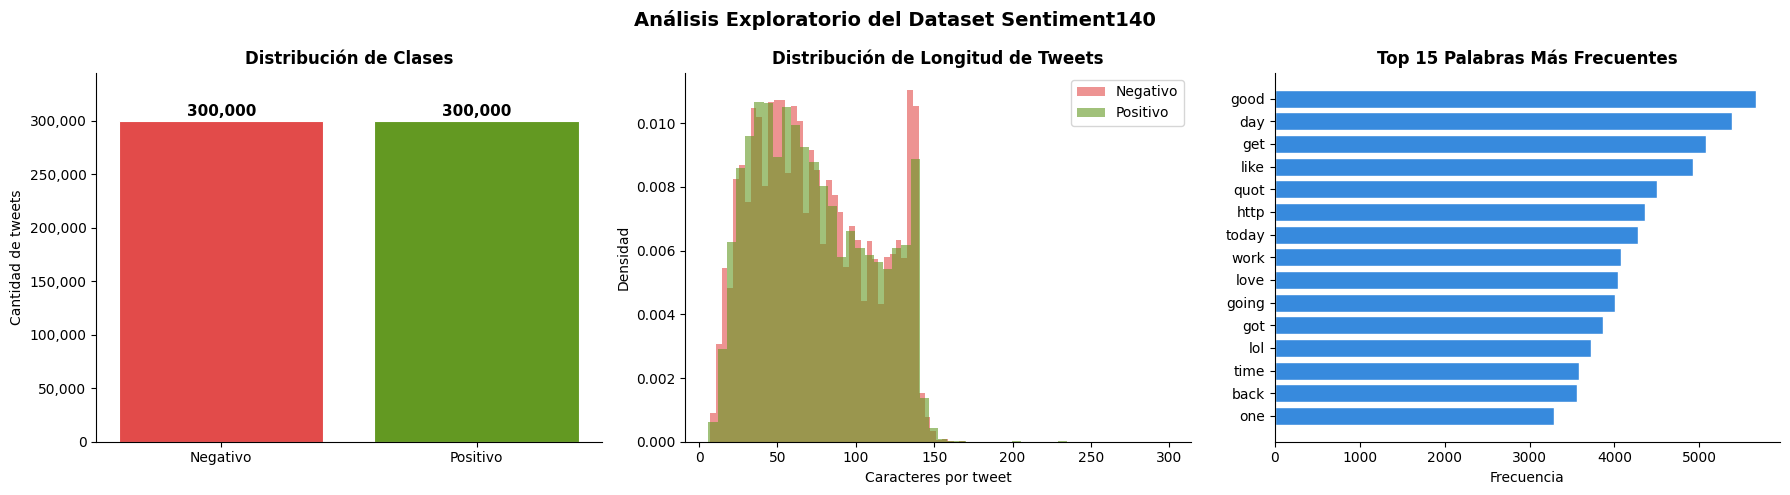


Estadísticas de longitud de tweets:
count    600000.00
mean         74.10
std          36.47
min           6.00
25%          44.00
50%          69.00
75%         104.00
max         359.00
Name: tweet_length, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Exploratorio del Dataset Sentiment140', fontsize=14, fontweight='bold')

# --- Gráfico 1: Distribución de clases ---
ax1 = axes[0]
labels = ['Negativo', 'Positivo']
colors_bar = ['#E24B4A', '#639922']
counts = df_bal['sentiment'].value_counts().sort_index()
bars = ax1.bar(labels, counts.values, color=colors_bar, edgecolor='white', linewidth=0.8)
ax1.set_title('Distribución de Clases', fontweight='bold')
ax1.set_ylabel('Cantidad de tweets')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(counts.values) * 1.15)
ax1.spines[['top', 'right']].set_visible(False)

# --- Gráfico 2: Longitud de tweets por clase ---
ax2 = axes[1]
df_bal['tweet_length'] = df_bal['text'].str.len()
sample = df_bal.groupby('sentiment').apply(lambda x: x.sample(min(50000, len(x)), random_state=42)).reset_index(drop=True)
for cls, label, color in zip([0, 1], labels, colors_bar):
    subset = sample[sample['sentiment'] == cls]['tweet_length']
    ax2.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
ax2.set_title('Distribución de Longitud de Tweets', fontweight='bold')
ax2.set_xlabel('Caracteres por tweet')
ax2.set_ylabel('Densidad')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

# --- Gráfico 3: Top palabras más frecuentes ---
ax3 = axes[2]
stop_words_set = set(stopwords.words('english'))
sample_text = ' '.join(df_bal['text'].sample(100000, random_state=42).tolist())
words = re.findall(r'\b[a-zA-Z]{3,}\b', sample_text.lower())
words_filtered = [w for w in words if w not in stop_words_set]
top_words = Counter(words_filtered).most_common(15)
word_labels = [w[0] for w in top_words]
word_counts = [w[1] for w in top_words]
ax3.barh(word_labels[::-1], word_counts[::-1], color='#378ADD', edgecolor='white')
ax3.set_title('Top 15 Palabras Más Frecuentes', fontweight='bold')
ax3.set_xlabel('Frecuencia')
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_sentiment140.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nEstadísticas de longitud de tweets:')
print(df_bal['tweet_length'].describe().round(2))

## 6. Preprocesamiento NLP

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_tweet(text):
    """
    Pipeline de preprocesamiento para tweets:
    1. Minúsculas
    2. Eliminar URLs
    3. Eliminar menciones (@usuario)
    4. Conservar texto de hashtags (#palabra → palabra)
    5. Eliminar números y caracteres especiales
    6. Eliminar stopwords
    7. Stemming (Porter)
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print(' Aplicando preprocesamiento NLP')
df_bal['clean_text'] = df_bal['text'].apply(preprocess_tweet)
df_final = df_bal[df_bal['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f'Tweets válidos: {len(df_final):,}')
print('\nEjemplos de preprocesamiento:')
for i in range(3):
    label = 'POS' if df_final['sentiment'].iloc[i] == 1 else 'NEG'
    print(f'  [{label}] Original : {df_final["text"].iloc[i]}')
    print(f'       Limpio   : {df_final["clean_text"].iloc[i]}')
    print()

 Aplicando preprocesamiento NLP
Tweets válidos: 597,013

Ejemplos de preprocesamiento:
  [NEG] Original : @xnausikaax oh no! where did u order from? that's horrible 
       Limpio   : oh order that horribl

  [NEG] Original : A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
       Limpio   : great hard train weekend coupl day rest let lot comput time put

  [NEG] Original : Right, off to work  Only 5 hours to go until I'm free xD
       Limpio   : right work hour go im free xd



## 7. Tokenización y Padding

In [7]:
MAX_VOCAB_SIZE = 50_000
MAX_SEQ_LENGTH = 50
EMBEDDING_DIM  = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df_final['clean_text'])

print(f'Tamaño del vocabulario total : {len(tokenizer.word_index):,}')
print(f'Vocabulario utilizado (top)  : {MAX_VOCAB_SIZE:,}')

sequences = tokenizer.texts_to_sequences(df_final['clean_text'])

seq_lengths = [len(s) for s in sequences]
print(f'\nEstadísticas de longitud de secuencias:')
print(f'  Media   : {np.mean(seq_lengths):.1f}')
print(f'  Mediana : {np.median(seq_lengths):.1f}')
print(f'  P95     : {np.percentile(seq_lengths, 95):.1f}')
print(f'  Max     : {max(seq_lengths)}')

X = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

y = df_final['sentiment'].values
y_cat = to_categorical(y, num_classes=2)

print(f'\nShape de X: {X.shape}')
print(f'Shape de y: {y_cat.shape}')

# Split 70 / 15 / 15
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

print(f'\nDivisión del dataset:')
print(f'  Train      : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Validación : {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  Test       : {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)')

Tamaño del vocabulario total : 181,333
Vocabulario utilizado (top)  : 50,000

Estadísticas de longitud de secuencias:
  Media   : 7.1
  Mediana : 7.0
  P95     : 14.0
  Max     : 28

Shape de X: (597013, 50)
Shape de y: (597013, 2)

División del dataset:
  Train      : 417,894 (70.0%)
  Validación : 89,567 (15.0%)
  Test       : 89,552 (15.0%)


## 8. Construcción del Modelo CNN + LSTM

In [8]:
def build_cnn_lstm_model(vocab_size, embedding_dim, max_seq_length, num_classes=2):
    """
    Arquitectura CNN + LSTM para clasificación de sentimientos.

    Flujo:
    Input → Embedding → Conv1D(k=3) → Conv1D(k=5) → BatchNorm
          → MaxPool → Dropout → LSTM → Dense → BatchNorm
          → Dropout → Softmax
    """
    inputs = Input(shape=(max_seq_length,), name='input_layer')

    # Embedding
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_seq_length,
        name='embedding'
    )(inputs)

    # Bloque CNN — extrae patrones locales (n-gramas)
    conv1 = Conv1D(128, kernel_size=3, activation='relu', padding='same', name='conv1d_1')(emb)
    conv1 = BatchNormalization(name='bn_1')(conv1)
    conv2 = Conv1D(128, kernel_size=5, activation='relu', padding='same', name='conv1d_2')(conv1)
    conv2 = BatchNormalization(name='bn_2')(conv2)
    pool  = MaxPooling1D(pool_size=2, name='maxpool')(conv2)
    pool  = Dropout(0.3, name='dropout_cnn')(pool)

    # Bloque LSTM — captura dependencias temporales
    lstm = LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.2,
        name='lstm'
    )(pool)

    # Capas densas
    dense = Dense(64, activation='relu', name='dense_1')(lstm)
    dense = BatchNormalization(name='bn_3')(dense)
    dense = Dropout(0.4, name='dropout_dense')(dense)

    outputs = Dense(num_classes, activation='softmax', name='output')(dense)

    model = Model(inputs=inputs, outputs=outputs, name='CNN_LSTM_Sentiment')
    return model


model = build_cnn_lstm_model(
    vocab_size=MAX_VOCAB_SIZE + 1,
    embedding_dim=EMBEDDING_DIM,
    max_seq_length=MAX_SEQ_LENGTH,
    num_classes=2
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print(f'\nParámetros totales: {model.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "CNN_LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 50, 100)        │     5,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 50, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_cnn (Dropout)           │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,261,926 (20.07 MB)

 Trainable params: 5,261,286 (20.07 MB)

 Non-trainable params: 640 (2.50 KB)


Parámetros totales: 5,261,926


## 9. Entrenamiento

In [9]:
BATCH_SIZE = 512
EPOCHS     = 15

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print('⏳ Iniciando entrenamiento...')
print(f'   Épocas máx: {EPOCHS} | Batch size: {BATCH_SIZE}')
print(f'   Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,}\n')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print('\n Entrenamiento finalizado')

⏳ Iniciando entrenamiento...
   Épocas máx: 15 | Batch size: 512
   Train: 417,894 | Val: 89,567

Epoch 1/15
817/817 ━━━━━━━━━━━━━━━━━━━━ 110s 117ms/step - accuracy: 0.5742 - loss: 0.6567 - val_accuracy: 0.6535 - val_loss: 1.0921 - learning_rate: 0.0010
Epoch 2/15
817/817 ━━━━━━━━━━━━━━━━━━━━ 136s 116ms/step - accuracy: 0.7867 - loss: 0.4561 - val_accuracy: 0.7206 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 3/15
817/817 ━━━━━━━━━━━━━━━━━━━━ 93s 114ms/step - accuracy: 0.8248 - loss: 0.3919 - val_accuracy: 0.7578 - val_loss: 0.5498 - learning_rate: 0.0010
Epoch 4/15
817/817 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8537 - loss: 0.3395
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
817/817 ━━━━━━━━━━━━━━━━━━━━ 94s 115ms/step - accuracy: 0.8627 - loss: 0.3221 - val_accuracy: 0.7598 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 5/15
817/817 ━━━━━━━━━━━━━━━━━━━━ 93s 113ms/step - accuracy: 0.8931 - loss: 0.2577 - val_accuracy: 0.7503 - val_loss: 0.7

## 10. Curvas de Entrenamiento

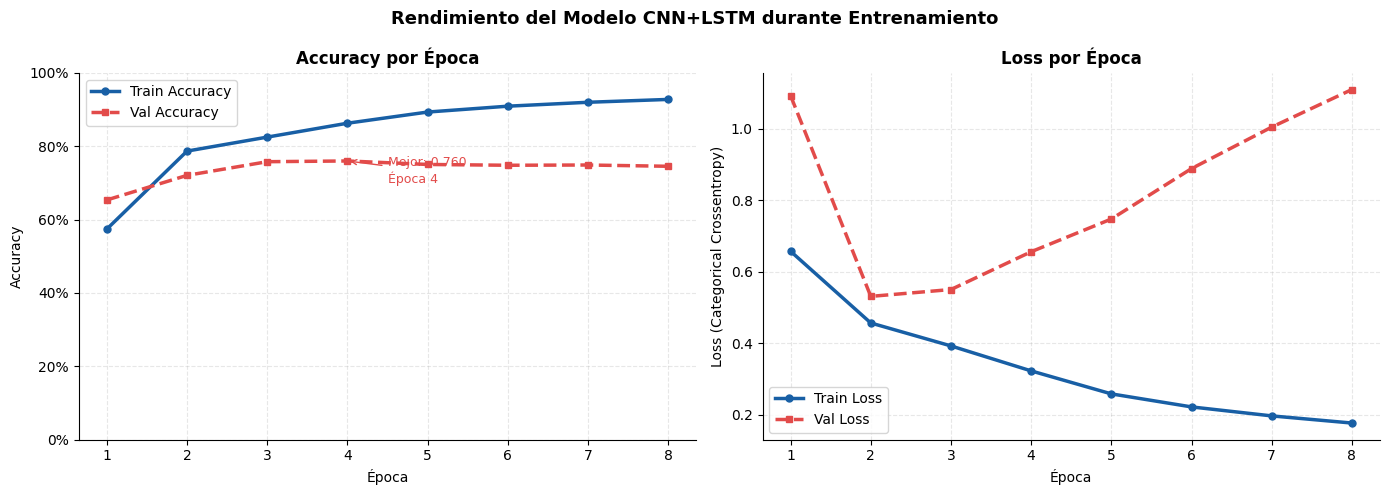

 Mejor Val Accuracy: 0.7598 (Época 4)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rendimiento del Modelo CNN+LSTM durante Entrenamiento',
             fontsize=13, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# --- Accuracy ---
ax1 = axes[0]
ax1.plot(epochs_range, history.history['accuracy'],
         color='#185FA5', linewidth=2.5, marker='o', markersize=5, label='Train Accuracy')
ax1.plot(epochs_range, history.history['val_accuracy'],
         color='#E24B4A', linewidth=2.5, marker='s', markersize=5,
         label='Val Accuracy', linestyle='--')
ax1.set_title('Accuracy por Época', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines[['top', 'right']].set_visible(False)

best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
ax1.annotate(f'Mejor: {best_val_acc:.3f}\nÉpoca {best_epoch}',
             xy=(best_epoch, best_val_acc),
             xytext=(best_epoch + 0.5, best_val_acc - 0.06),
             fontsize=9, color='#E24B4A',
             arrowprops=dict(arrowstyle='->', color='#E24B4A'))

# --- Loss ---
ax2 = axes[1]
ax2.plot(epochs_range, history.history['loss'],
         color='#185FA5', linewidth=2.5, marker='o', markersize=5, label='Train Loss')
ax2.plot(epochs_range, history.history['val_loss'],
         color='#E24B4A', linewidth=2.5, marker='s', markersize=5,
         label='Val Loss', linestyle='--')
ax2.set_title('Loss por Época', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss (Categorical Crossentropy)')
ax2.legend()
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Mejor Val Accuracy: {best_val_acc:.4f} (Época {best_epoch})')

## 11. Evaluación en el Conjunto de Test

In [11]:
print(' Evaluando modelo en conjunto de test')
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print('\n' + '='*50)
print('      RESULTADOS EN CONJUNTO DE TEST')
print('='*50)
print(f'  Loss     : {test_loss:.4f}')
print(f'  Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print('='*50)

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = ['Negativo', 'Positivo']
print('\nReporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

 Evaluando modelo en conjunto de test

      RESULTADOS EN CONJUNTO DE TEST
  Loss     : 0.6463
  Accuracy : 0.7637 (76.37%)

Reporte de Clasificación:
              precision    recall  f1-score   support

    Negativo     0.7752    0.7429    0.7587     44790
    Positivo     0.7531    0.7845    0.7684     44762

    accuracy                         0.7637     89552
   macro avg     0.7641    0.7637    0.7636     89552
weighted avg     0.7642    0.7637    0.7636     89552



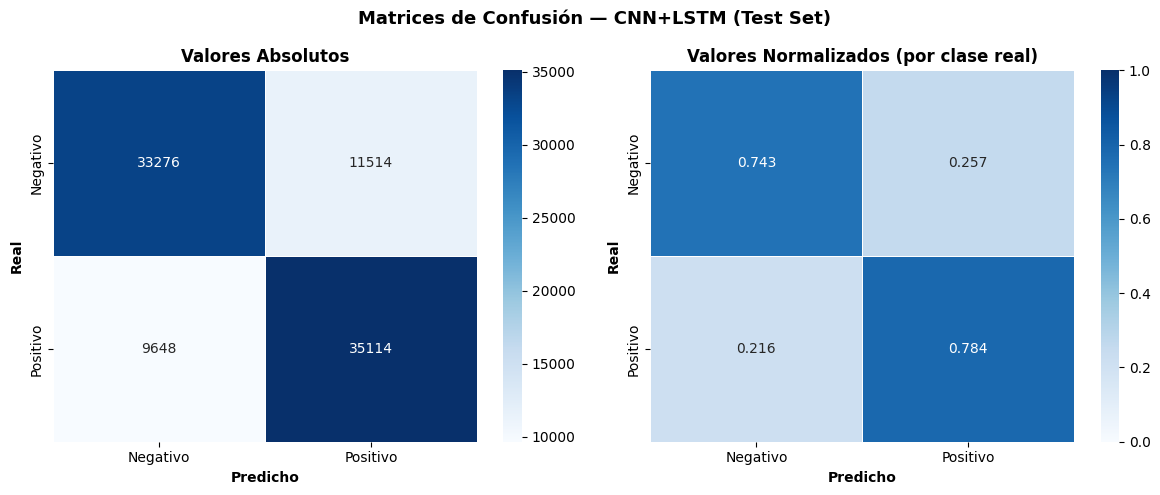

In [12]:
# --- Matriz de Confusión ---
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión — CNN+LSTM (Test Set)', fontsize=13, fontweight='bold')

ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax1, linewidths=0.5, linecolor='white')
ax1.set_title('Valores Absolutos', fontweight='bold')
ax1.set_xlabel('Predicho', fontweight='bold')
ax1.set_ylabel('Real', fontweight='bold')

ax2 = axes[1]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax2, linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax2.set_title('Valores Normalizados (por clase real)', fontweight='bold')
ax2.set_xlabel('Predicho', fontweight='bold')
ax2.set_ylabel('Real', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

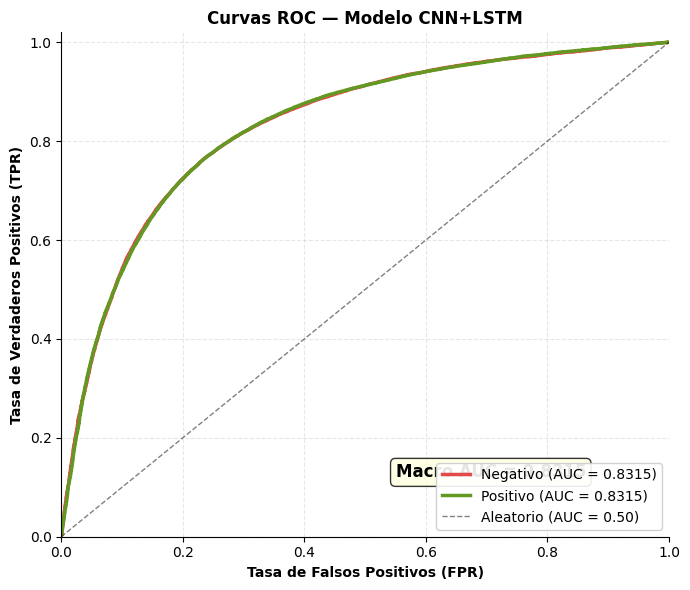

AUC por clase:
  Negativo: 0.8315
  Positivo: 0.8315
  Macro AUC: 0.8315


In [13]:
# --- Curva ROC ---
fig, ax = plt.subplots(figsize=(7, 6))

colors = ['#E24B4A', '#639922']
auc_scores = []

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, i], pos_label=i)
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{class_name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Aleatorio (AUC = 0.50)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontweight='bold')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontweight='bold')
ax.set_title('Curvas ROC — Modelo CNN+LSTM', fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
ax.text(0.55, 0.12, f'Macro AUC = {np.mean(auc_scores):.4f}',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('AUC por clase:')
for name, score in zip(class_names, auc_scores):
    print(f'  {name}: {score:.4f}')
print(f'  Macro AUC: {np.mean(auc_scores):.4f}')

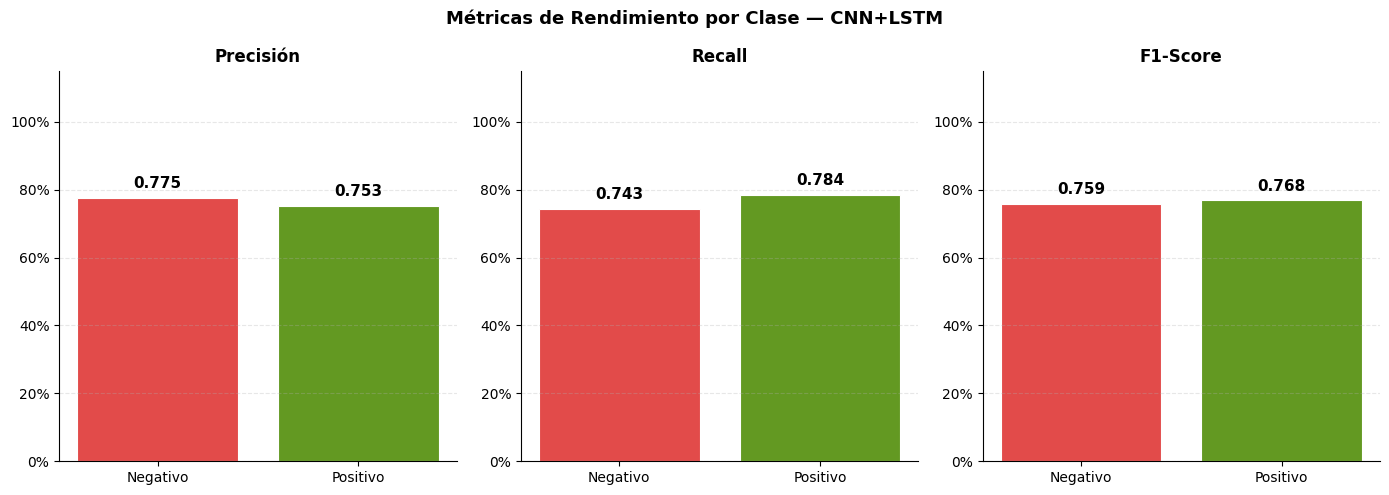


  RESUMEN FINAL
  Test Accuracy  : 0.7637 (76.37%)
  Test Loss      : 0.6463
  Macro F1-Score : 0.7636
  Macro Precision: 0.7641
  Macro Recall   : 0.7637
  Macro AUC      : 0.8315


In [14]:
# --- Métricas por clase ---
report_dict = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Métricas de Rendimiento por Clase — CNN+LSTM', fontsize=13, fontweight='bold')

metrics_to_plot = ['precision', 'recall', 'f1-score']
metric_titles   = ['Precisión', 'Recall', 'F1-Score']
palette = ['#E24B4A', '#639922']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx]
    values = [report_dict[cls][metric] for cls in class_names]
    bars = ax.bar(class_names, values, color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('  RESUMEN FINAL')
print('='*55)
print(f'  Test Accuracy  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  Macro F1-Score : {report_dict["macro avg"]["f1-score"]:.4f}')
print(f'  Macro Precision: {report_dict["macro avg"]["precision"]:.4f}')
print(f'  Macro Recall   : {report_dict["macro avg"]["recall"]:.4f}')
print(f'  Macro AUC      : {np.mean(auc_scores):.4f}')
print('='*55)

## 12. Predicción en Tiempo Real

In [15]:
SENTIMENT_LABELS = {
    0: '🔴 Negativo',
    1: '🟢 Positivo'
}

def predict_sentiment(texts, model, tokenizer, max_len=MAX_SEQ_LENGTH):
    if isinstance(texts, str):
        texts = [texts]

    cleaned = [preprocess_tweet(t) for t in texts]
    seqs    = tokenizer.texts_to_sequences(cleaned)
    padded  = pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
    probas  = model.predict(padded, verbose=0)

    results = []
    for orig, proba in zip(texts, probas):
        pred_class = np.argmax(proba)
        results.append({
            'texto_original': orig,
            'sentimiento':    SENTIMENT_LABELS[pred_class],
            'confianza':      f'{proba[pred_class]*100:.1f}%',
            'prob_negativo':  f'{proba[0]*100:.1f}%',
            'prob_positivo':  f'{proba[1]*100:.1f}%',
        })
    return results


test_tweets = [
    "I absolutely love this new update! Best thing ever 😍",
    "This product is terrible, complete waste of money! 😡",
    "Just watched the game, it was amazing! Go team!! 🎉",
    "@user can't believe how bad this service is, never again!",
    "Thank you so much for your help, really appreciate it!",
    "Worst customer service I've ever experienced. Disgusting.",
    "Feeling so happy today, everything is going great!",
    "I hate Mondays, nothing ever works out."
]

results = predict_sentiment(test_tweets, model, tokenizer)

print('\n' + '='*70)
print('      PREDICCIONES EN TIEMPO REAL')
print('='*70)
for r in results:
    print(f"\nTexto   : {r['texto_original']}")
    print(f"Sentim. : {r['sentimiento']}  (confianza: {r['confianza']})")
    print(f"Prob.   : NEG={r['prob_negativo']}  POS={r['prob_positivo']}")
    print('-' * 70)


      PREDICCIONES EN TIEMPO REAL

Texto   : I absolutely love this new update! Best thing ever 😍
Sentim. : 🟢 Positivo  (confianza: 96.6%)
Prob.   : NEG=3.4%  POS=96.6%
----------------------------------------------------------------------

Texto   : This product is terrible, complete waste of money! 😡
Sentim. : 🔴 Negativo  (confianza: 99.1%)
Prob.   : NEG=99.1%  POS=0.9%
----------------------------------------------------------------------

Texto   : Just watched the game, it was amazing! Go team!! 🎉
Sentim. : 🟢 Positivo  (confianza: 99.5%)
Prob.   : NEG=0.5%  POS=99.5%
----------------------------------------------------------------------

Texto   : @user can't believe how bad this service is, never again!
Sentim. : 🔴 Negativo  (confianza: 92.8%)
Prob.   : NEG=92.8%  POS=7.2%
----------------------------------------------------------------------

Texto   : Thank you so much for your help, really appreciate it!
Sentim. : 🟢 Positivo  (confianza: 99.7%)
Prob.   : NEG=0.3%  POS=99.7%
-

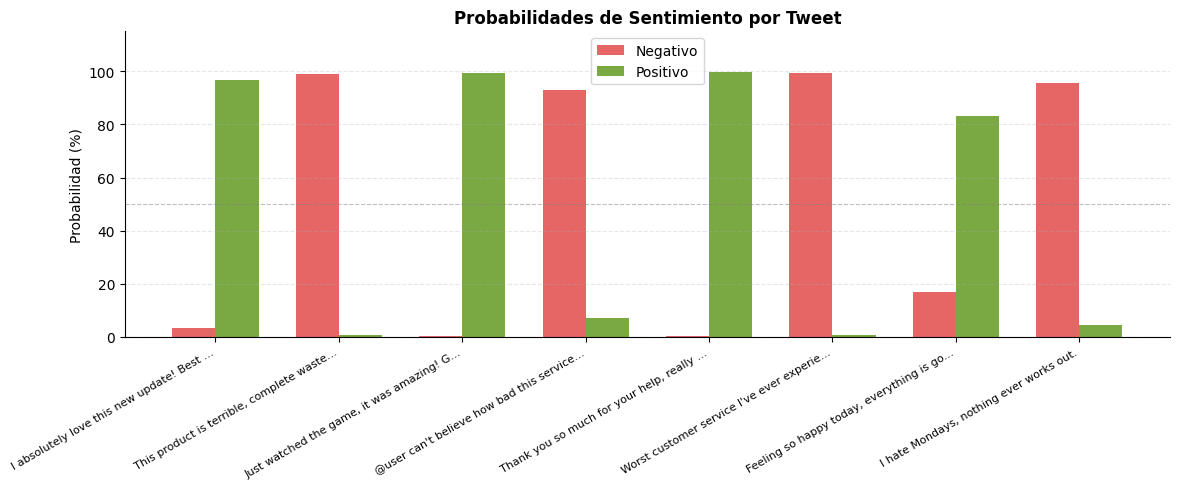

In [16]:
# --- Visualización de predicciones ---
fig, ax = plt.subplots(figsize=(12, 5))

n = len(results)
x = np.arange(n)
width = 0.35

neg_probs = [float(r['prob_negativo'].replace('%', '')) for r in results]
pos_probs = [float(r['prob_positivo'].replace('%', '')) for r in results]

ax.bar(x - width/2, neg_probs, width, label='Negativo', color='#E24B4A', alpha=0.85)
ax.bar(x + width/2, pos_probs, width, label='Positivo', color='#639922', alpha=0.85)

short_labels = [t[:40] + '...' if len(t) > 40 else t for t in test_tweets]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Probabilidad (%)')
ax.set_title('Probabilidades de Sentimiento por Tweet', fontweight='bold')
ax.legend()
ax.set_ylim(0, 115)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('realtime_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Guardar el Modelo

In [17]:
import pickle, json

model.save('cnn_lstm_sentiment_model.keras')
print('Modelo guardado: cnn_lstm_sentiment_model.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizador guardado: tokenizer.pkl')

with open('training_history.json', 'w') as f:
    json.dump(history.history, f)
print('Historial guardado: training_history.json')

print('\n' + '='*55)
print('  ARCHIVOS GENERADOS')
print('='*55)
print('  📦 cnn_lstm_sentiment_model.keras')
print('  📦 tokenizer.pkl')
print('  📦 training_history.json')
print('  📊 eda_sentiment140.png')
print('  📊 training_curves.png')
print('  📊 confusion_matrix.png')
print('  📊 roc_curves.png')
print('  📊 metrics_per_class.png')
print('  📊 realtime_predictions.png')
print('='*55)

Modelo guardado: cnn_lstm_sentiment_model.keras
Tokenizador guardado: tokenizer.pkl
Historial guardado: training_history.json

  ARCHIVOS GENERADOS
  📦 cnn_lstm_sentiment_model.keras
  📦 tokenizer.pkl
  📦 training_history.json
  📊 eda_sentiment140.png
  📊 training_curves.png
  📊 confusion_matrix.png
  📊 roc_curves.png
  📊 metrics_per_class.png
  📊 realtime_predictions.png
